In [12]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from dotenv import load_dotenv
import os


In [13]:
class QuadraticState(TypedDict):
    a: float
    b: float
    c: float

    equation: str
    discriminant: float
    result: str

In [14]:
def show_eq(state: QuadraticState) -> QuadraticState:
    equation = f'{state["a"]}x^2 + {state["b"]}x + {state["c"]} = 0'
    return {"equation": equation}

def calculate_disc(state: QuadraticState) -> QuadraticState:
    discriminant = state["b"]**2 - 4*state["a"]*state["c"]
    return {"discriminant": discriminant}

In [15]:
def real_roots(state: QuadraticState) -> QuadraticState:
    
    root1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])
    result = f"Two real roots: {root1} and {root2}"
    
    return {"result": result}

In [21]:
def same_root(state: QuadraticState) -> QuadraticState:
    root = -state['b'] / (2*state['a'])
    result = f"One real root: {root}"
    
    return {"result": result}

In [22]:
def no_real_root(state: QuadraticState) -> QuadraticState:
    result = "No real roots"
    return {"result": result}

In [23]:
def check_disc(state: QuadraticState) -> Literal["two_real", "one_real", "no_real"]:
    if state["discriminant"] > 0:
        return "two_real"
    elif state["discriminant"] == 0:
        return "one_real"
    else:
        return "no_real"

In [24]:
graph = StateGraph(QuadraticState)

graph.add_node('show_eq', show_eq)
graph.add_node('calculate_disc', calculate_disc)
graph.add_node('real_roots', real_roots)
graph.add_node('same_root', same_root)
graph.add_node('no_real_root', no_real_root)

graph.add_edge(START, 'show_eq')
graph.add_edge('show_eq', 'calculate_disc')

graph.add_conditional_edges('calculate_disc', check_disc, {
    "two_real": "real_roots",
    "one_real": "same_root",
    "no_real": "no_real_root"
})
graph.add_edge('real_roots', END)
graph.add_edge('same_root', END)
graph.add_edge('no_real_root', END)

workflow = graph.compile()


In [25]:
inintial_state = {
    "a": 1,
    "b": -3,
    "c": 2
}

workflow.invoke(inintial_state)

{'a': 1,
 'b': -3,
 'c': 2,
 'equation': '1x^2 + -3x + 2 = 0',
 'discriminant': 1,
 'result': 'Two real roots: 2.0 and 1.0'}

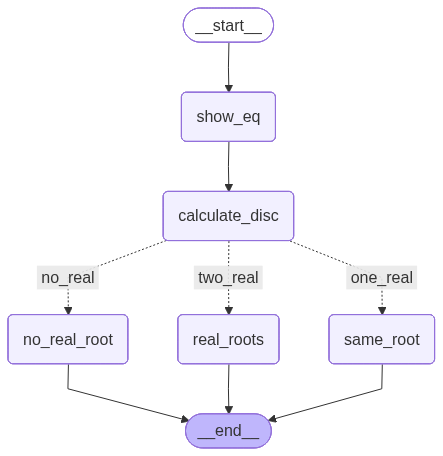

In [26]:
workflow